## Importing data and libraries

In [1]:
from pyexpat import features

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
train_identity = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_identity.csv")
train_transaction = pd.read_csv("~/ML/Data/ieee-fraud-detection/train_transaction.csv")
x_train = train_identity.merge(train_transaction, how="left", on="TransactionID")


## Visualizing transaction amount

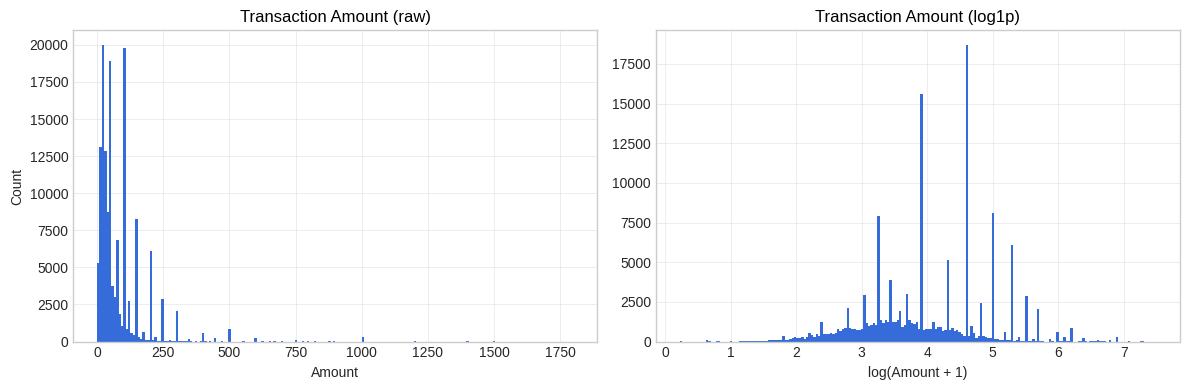

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_train['TransactionAmt'], bins=200)
axes[0].set_title('Transaction Amount (raw)', color='black')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')
axes[1].hist(np.log1p(x_train['TransactionAmt']), bins=200)
axes[1].set_title('Transaction Amount (log1p)', color='black')
axes[1].set_xlabel('log(Amount + 1)')
plt.tight_layout()
fig.savefig('transaction_distribution.png', bbox_inches='tight')
plt.show()


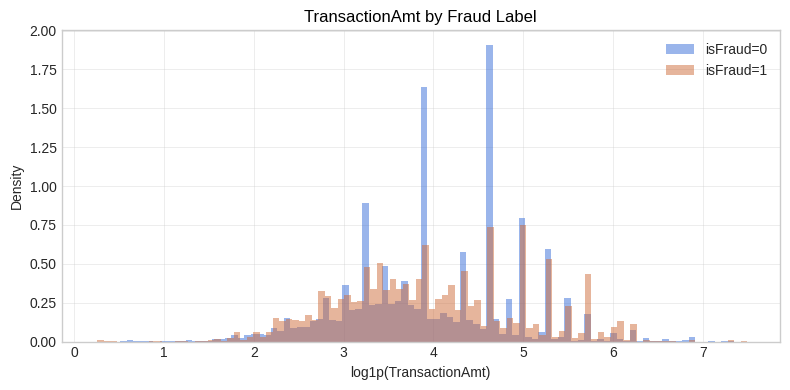

In [121]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in x_train.groupby('isFraud'):
    ax.hist(np.log1p(group['TransactionAmt']), bins=100, alpha=0.5,
            label=f'isFraud={label}', density=True)
ax.set_xlabel('log1p(TransactionAmt)')
ax.set_ylabel('Density')
ax.set_title('TransactionAmt by Fraud Label', color='black')
ax.legend()
plt.tight_layout()
plt.show()


In [3]:
x_train['TransactionAmt'] = np.log1p(x_train['TransactionAmt'])


## Visualizing imbalanced data

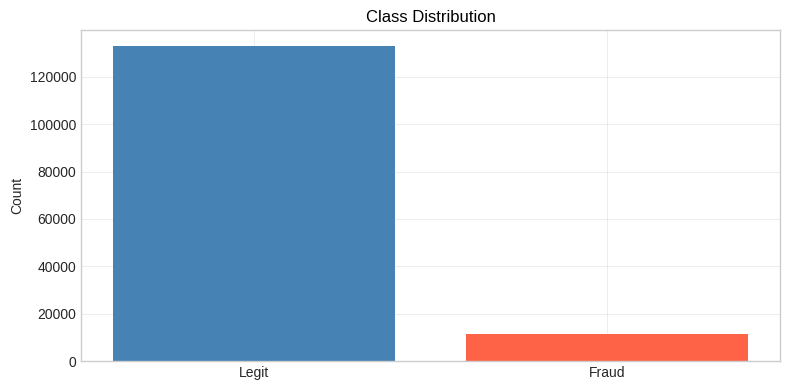

In [123]:
fig, ax = plt.subplots(figsize=(8, 4))
counts = x_train.groupby('isFraud')['TransactionID'].count()
ax.bar(counts.index, counts.values, color=['steelblue', 'tomato'])
ax.set_xticks([0, 1])
ax.set_xticklabels(['Legit', 'Fraud'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution', color='black')
plt.tight_layout()
fig.savefig('class_distribution.png', bbox_inches='tight')
plt.show()


## Visualizing fraud against time

/tmp/ipykernel_3092/2423469860.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train["DT_day"] = (x_train["TransactionDT"] // (3600 * 24)) % 7
/tmp/ipykernel_3092/2423469860.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  x_train["DT_hour"] = (x_train["TransactionDT"] // 3600) % 24
/tmp/ipykernel_3092/2423469860.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis

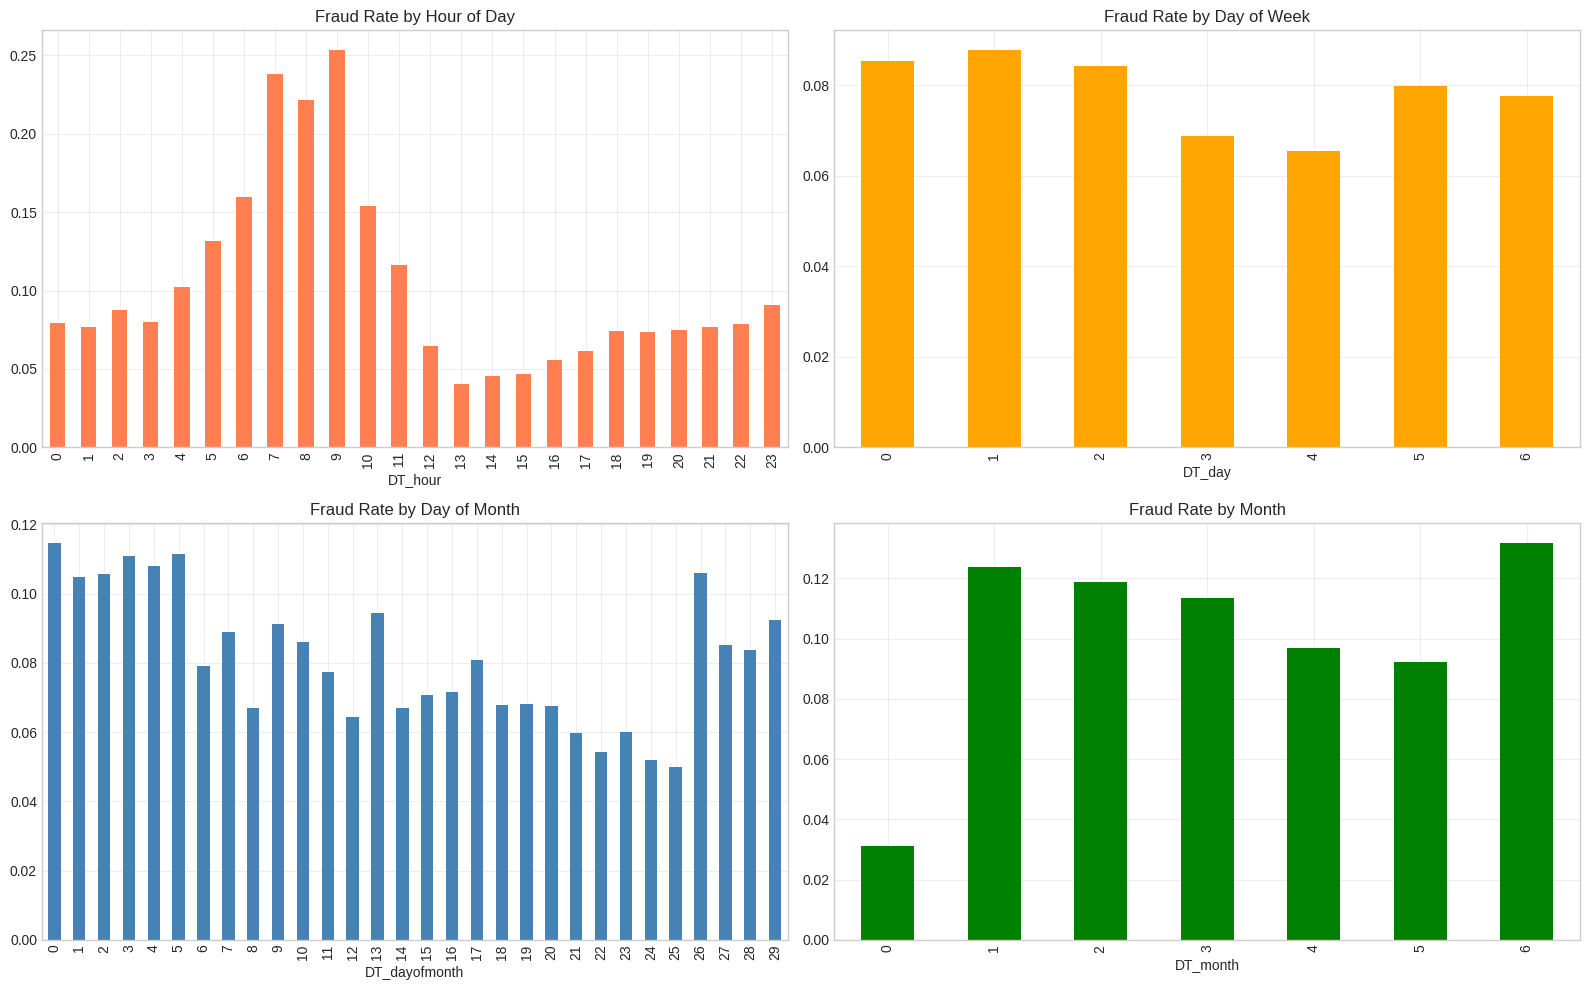

In [4]:
plt.close("all")

x_train["DT_day"] = (x_train["TransactionDT"] // (3600 * 24)) % 7
x_train["DT_hour"] = (x_train["TransactionDT"] // 3600) % 24
x_train["DT_dayofmonth"] = (x_train["TransactionDT"] // (3600 * 24)) % 30
x_train["DT_month"] = (x_train["TransactionDT"] // (3600 * 24)) // 30

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x_train.groupby("DT_hour")["isFraud"].mean().plot(
    kind="bar", ax=axes[0, 0], title="Fraud Rate by Hour of Day", color="coral")
x_train.groupby("DT_day")["isFraud"].mean().plot(
    kind="bar", ax=axes[0, 1], title="Fraud Rate by Day of Week", color="orange")
x_train.groupby("DT_dayofmonth")["isFraud"].mean().plot(
    kind="bar", ax=axes[1, 0], title="Fraud Rate by Day of Month", color="steelblue")
x_train.groupby("DT_month")["isFraud"].mean().plot(
    kind="bar", ax=axes[1, 1], title="Fraud Rate by Month", color="green")
plt.tight_layout()
plt.savefig("fraud_by_time_features.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()


## Handling missing values

In [5]:
def na_to_cols(df, threshold=0.6):
    cols_to_transform = df.columns[df.isna().mean() > threshold]
    nan_flags = pd.concat(
        [df[col].isnull().astype(int).rename(col + '_isNaN') for col in cols_to_transform],
        axis=1
    )
    df = pd.concat([df, nan_flags], axis=1)
    df = df.drop(columns=cols_to_transform)
    return df

df_clean = na_to_cols(x_train, threshold=0.6)
df_clean = na_to_cols(df_clean, threshold=0.17)


## Imputing missing values

In [6]:
def impute_missing(df, num_strategy="median", cat_fill="missing"):
    df = df.copy()
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=["object"]).columns
    if num_strategy == "median":
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    elif num_strategy == "mean":
        df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
    df[cat_cols] = df[cat_cols].fillna(cat_fill)
    return df

df_clean_t = impute_missing(df_clean, num_strategy="median", cat_fill="missing")


/tmp/ipykernel_3092/777359881.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


## Encoding categorical features

In [7]:
nunique = df_clean_t.select_dtypes(include='object').nunique()
low_card_cols = nunique[nunique < 5].index.tolist()
df_clean_t = pd.get_dummies(df_clean_t, columns=low_card_cols, drop_first=True, dtype=int)


/tmp/ipykernel_3092/1479662264.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  nunique = df_clean_t.select_dtypes(include='object').nunique()


## Mean encoding high cardinality columns

In [8]:
high_card_cols = df_clean_t.select_dtypes(include='object').columns.tolist()
for col in high_card_cols:
    mean_map = df_clean_t.groupby(col)['isFraud'].mean()
    df_clean_t[col] = df_clean_t[col].map(mean_map)


/tmp/ipykernel_3092/1142308157.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  high_card_cols = df_clean_t.select_dtypes(include='object').columns.tolist()


## Separating target and dropping ID columns

In [9]:
y = df_clean_t['isFraud'].astype(int)
df_clean_t = df_clean_t.drop(columns=['isFraud', 'TransactionID'])

print(df_clean_t.shape)
print(df_clean_t.dtypes.value_counts())
print(df_clean_t.isna().sum().sum())


(144233, 450)
float64    230
int64      220
Name: count, dtype: int64
0


## Time based train/valid split

In [10]:
df_clean_t = df_clean_t.sort_values("TransactionDT",ascending=True)
split_idx = int(len(df_clean_t)*0.8)

x_train = df_clean_t[:split_idx].drop(columns="TransactionDT")
x_valid = df_clean_t.iloc[split_idx:].drop(columns="TransactionDT")
y_train = y.iloc[:split_idx]
y_valid = y.iloc[split_idx:]

## Correlation filter

In [11]:
import importlib
import corr_filter
importlib.reload(corr_filter)
from corr_filter import filter
x_train_filtered,x_valid_filtered = filter(x_train, y_train, threshold=0.6,x_valid=x_valid)

/home/ldavi/ML/IEEE_CIS_Fraud_Detection/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
print(x_train_filtered.shape)

(115386, 101)


## Training baseline model

In [13]:
from xgboost import XGBClassifier

model = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    gamma=0.1
)

model.fit(x_train_filtered, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_train_filtered)

shap_importance = pd.DataFrame({
    'feature' : x_train_filtered.columns,
    'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance',ascending=False)

print(shap_importance.head(20))
print(f'\nFeatures with importance > 0.001: {(shap_importance["importance"] > 0.001).sum()}')
print(f'Features with importance < 0.001: {(shap_importance["importance"] < 0.001).sum()}')



           feature  importance
16              C2    0.621878
60        DT_month    0.494648
15   R_emaildomain    0.400438
10  TransactionAmt    0.268253
42            V257    0.228975
9            id_31    0.214002
6            id_17    0.202710
99    card6_credit    0.169296
97     ProductCD_R    0.159917
12           card2    0.158918
65        D2_isNaN    0.142555
11           card1    0.119343
31            V199    0.099496
8            id_20    0.093007
46            V274    0.088182
0            id_01    0.084606
96     ProductCD_H    0.084396
20              D1    0.079579
1            id_02    0.078920
2            id_05    0.063695

Features with importance > 0.001: 70
Features with importance < 0.001: 31


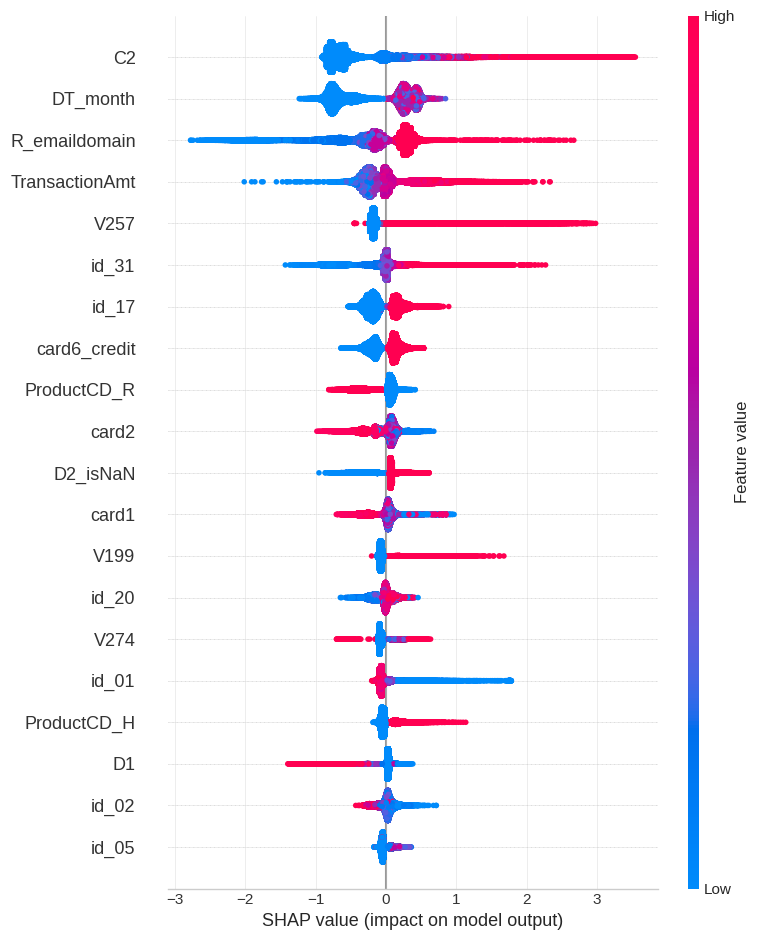

In [15]:
shap.summary_plot(shap_values, x_train_filtered, max_display=20)

In [16]:
features_to_drop = shap_importance.sort_values('importance',ascending=True)['feature'].head(31).to_list()

In [17]:
x_train_filtered = x_train_filtered.drop(columns=features_to_drop)

In [18]:
x_train_filtered.shape

(115386, 70)

In [19]:
x_valid_filtered = x_valid_filtered.drop(columns=features_to_drop)

In [20]:
y_train.value_counts()[0]/y_train.value_counts()[1]

np.float64(12.34559333795975)

## Optimizing Model

In [22]:
from sklearn.model_selection import StratifiedKFold,RandomizedSearchCV
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth' : [3,4,6],
    'min_child_weight': [5,8,10],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'reg_alpha' : [0,0.1,0.5,1],
    'reg_lambda' : [0.5,1.0,2.0],
    'gamma' : [0,0.1,0.5,1],
    'scale_pos_weight' : [12.3]
}

model = XGBClassifier(
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

grid = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)

In [178]:
result = grid.fit(x_train_filtered, y_train)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.8, gamma=0.5, max_depth=4, min_child_weight=8, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.2s
[CV] END colsample_bytree=0.8, gamma=0.5, max_depth=4, min_child_weight=8, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.4s
[CV] END colsample_bytree=0.8, gamma=0, max_depth=3, min_child_weight=10, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.9; total time=   2.2s
[CV] END colsample_bytree=0.8, gamma=0.5, max_depth=4, min_child_weight=8, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.3s
[CV] END colsample_bytree=0.8, gamma=0, max_depth=3, min_child_weight=10, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.9; total time=   2.0s
[CV] END colsample_bytree=0.8, gamma=0, max_depth=3, min_child_weight=10, reg_alpha=0.1, reg_lambda=0.5, scale_pos_weight=12

In [185]:
result.best_score_
x_valid_filtered.shape[1]

70

In [187]:
import dagshub
import mlflow
from sklearn.metrics import roc_auc_score
dagshub.init(repo_owner='ldavi22', repo_name='IEEE_CIS_Fraud_Detection', mlflow=True)

best_model = result.best_estimator_
y_valid_pred = best_model.predict_proba(x_valid_filtered)[:, 1]
valid_auc = roc_auc_score(y_valid, y_valid_pred)
mlflow.set_experiment("XGBoost_Tuning")

with mlflow.start_run(run_name="XGBoost_v1"):

    mlflow.set_tag("preprocessing", "High NaN Dropping / Mean-Median Fill")
    mlflow.set_tag("data_split", "Time-Based Split")
    mlflow.set_tag("algorithm", "XGBoost")

    for key,val in result.best_params_.items():
        mlflow.log_param(key,val)

    mlflow.log_param("n_features", x_valid_filtered.shape[1])
    mlflow.log_param("train_samples", x_valid_filtered.shape[0])

    mlflow.log_metric("train_auc",result.best_score_)
    mlflow.log_metric("valid_auc",valid_auc)

Initialized MLflow to track repo "ldavi22/IEEE_CIS_Fraud_Detection"

Repository ldavi22/IEEE_CIS_Fraud_Detection initialized!

2026/06/04 13:52:09 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Tuning' does not exist. Creating a new experiment.


🏃 View run XGBoost_v1 at: https://dagshub.com/ldavi22/IEEE_CIS_Fraud_Detection.mlflow/#/experiments/1/runs/598775576e624f9fab090295bd50e1cb
🧪 View experiment at: https://dagshub.com/ldavi22/IEEE_CIS_Fraud_Detection.mlflow/#/experiments/1


#### Tweaking learning rate and max_depth to make model not overfit

In [189]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth' : [3,4],
    'min_child_weight': [5,8,10],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'reg_alpha' : [0,0.1,0.5,1],
    'reg_lambda' : [0.5,1.0,2.0],
    'gamma' : [0,0.1,0.5,1],
    'scale_pos_weight' : [12.3]
}

model = XGBClassifier(
    learning_rate=0.05,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

grid = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)

In [190]:
import dagshub
import mlflow
from sklearn.metrics import roc_auc_score
dagshub.init(repo_owner='ldavi22', repo_name='IEEE_CIS_Fraud_Detection', mlflow=True)

result = grid.fit(x_train_filtered, y_train)
best_model = result.best_estimator_
y_valid_pred = best_model.predict_proba(x_valid_filtered)[:, 1]
valid_auc = roc_auc_score(y_valid, y_valid_pred)
mlflow.set_experiment("XGBoost_Tuning")

with mlflow.start_run(run_name="XGBoost_v2"):

    mlflow.set_tag("preprocessing", "High NaN Dropping / Mean-Median Fill")
    mlflow.set_tag("data_split", "Time-Based Split")
    mlflow.set_tag("algorithm", "XGBoost")

    for key,val in result.best_params_.items():
        mlflow.log_param(key,val)

    mlflow.log_param("n_features", x_valid_filtered.shape[1])
    mlflow.log_param("validation_samples", x_valid_filtered.shape[0])

    mlflow.log_metric("train_auc",result.best_score_)
    mlflow.log_metric("valid_auc",valid_auc)

Initialized MLflow to track repo "ldavi22/IEEE_CIS_Fraud_Detection"

Repository ldavi22/IEEE_CIS_Fraud_Detection initialized!

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=5, reg_alpha=0.5, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.3s
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=5, reg_alpha=0.5, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=5, reg_alpha=0.5, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=1, max_depth=4, min_child_weight=8, reg_alpha=0.5, reg_lambda=2.0, scale_pos_weight=12.3, subsample=0.9; total time=   2.8s
[CV] END colsample_bytree=0.8, gamma=1, max_depth=4, min_child_weight=8, reg_alpha=0.5, reg_lambda=2.0, scale_pos_weight=12.3, subsample=0.9; total time=   2.8s
[CV] END colsample_bytree=0.8, gamma=1, max_depth=4, min_child_weight=8, reg_alpha=0.5, reg_lambda=2.0, scale_pos_weight=12.3,

## Tweaking

In [27]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth' : [3],
    'min_child_weight': [5,8,10],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'reg_alpha' : [0,0.1,0.5,1],
    'reg_lambda' : [0.5,1.0,2.0],
    'gamma' : [0,0.1,0.5,1],
    'scale_pos_weight' : [12.3]
}

model = XGBClassifier(
    learning_rate=0.02,
    n_estimators=100,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

grid = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)

In [30]:
import dagshub
import mlflow
from sklearn.metrics import roc_auc_score
dagshub.init(repo_owner='ldavi22', repo_name='IEEE_CIS_Fraud_Detection', mlflow=True)
from mlflow.models.signature import infer_signature

# result = grid.fit(x_train_filtered, y_train)
# best_model = result.best_estimator_
# y_valid_pred = best_model.predict_proba(x_valid_filtered)[:, 1]
# valid_auc = roc_auc_score(y_valid, y_valid_pred)
# mlflow.set_experiment("XGBoost_Tuning")

with mlflow.start_run(run_name="XGBoost_v3"):

    mlflow.set_tag("preprocessing", "High NaN Dropping / Mean-Median Fill")
    mlflow.set_tag("data_split", "Time-Based Split")
    mlflow.set_tag("algorithm", "XGBoost")

    for key,val in result.best_params_.items():
        mlflow.log_param(key,val)

    mlflow.log_param("n_features", x_valid_filtered.shape[1])
    mlflow.log_param("validation_samples", x_valid_filtered.shape[0])

    mlflow.log_metric("train_auc",result.best_score_)
    mlflow.log_metric("valid_auc",valid_auc)
    signature = infer_signature(x_valid_filtered, y_valid_pred)

    mlflow.sklearn.log_model(
        best_model,
        "xgboost_model",
        signature=signature,
    )

Initialized MLflow to track repo "ldavi22/IEEE_CIS_Fraud_Detection"

Repository ldavi22/IEEE_CIS_Fraud_Detection initialized!

/home/ldavi/ML/IEEE_CIS_Fraud_Detection/.venv/lib/python3.14/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/06/08 10:57:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/08 10:57:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format

🏃 View run XGBoost_v3 at: https://dagshub.com/ldavi22/IEEE_CIS_Fraud_Detection.mlflow/#/experiments/1/runs/cbaf8077b18b406d98f318d9c034660c
🧪 View experiment at: https://dagshub.com/ldavi22/IEEE_CIS_Fraud_Detection.mlflow/#/experiments/1


In [23]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth' : [3,5],
    'min_child_weight': [5,8,10],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'reg_alpha' : [0,0.1,0.5,1],
    'reg_lambda' : [0.5,1.0,2.0],
    'gamma' : [0,0.1,0.5,1],
    'scale_pos_weight' : [12.3]
}

model = XGBClassifier(
    learning_rate=0.02,
    n_estimators=200,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

grid = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)


In [24]:
import dagshub
import mlflow
from sklearn.metrics import roc_auc_score
dagshub.init(repo_owner='ldavi22', repo_name='IEEE_CIS_Fraud_Detection', mlflow=True)

result = grid.fit(x_train_filtered, y_train)
best_model = result.best_estimator_
y_valid_pred = best_model.predict_proba(x_valid_filtered)[:, 1]
valid_auc = roc_auc_score(y_valid, y_valid_pred)
mlflow.set_experiment("XGBoost_Tuning")

with mlflow.start_run(run_name="XGBoost_v4"):

    mlflow.set_tag("preprocessing", "High NaN Dropping / Mean-Median Fill")
    mlflow.set_tag("data_split", "Time-Based Split")
    mlflow.set_tag("algorithm", "XGBoost")

    for key,val in result.best_params_.items():
        mlflow.log_param(key,val)

    mlflow.log_param("n_features", x_valid_filtered.shape[1])
    mlflow.log_param("validation_samples", x_valid_filtered.shape[0])

    mlflow.log_metric("train_auc",result.best_score_)
    mlflow.log_metric("valid_auc",valid_auc)

Accessing as ldavi22

Initialized MLflow to track repo "ldavi22/IEEE_CIS_Fraud_Detection"

Repository ldavi22/IEEE_CIS_Fraud_Detection initialized!

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.8, gamma=1, max_depth=3, min_child_weight=8, reg_alpha=1, reg_lambda=1.0, scale_pos_weight=12.3, subsample=0.8; total time=   4.5s
[CV] END colsample_bytree=0.8, gamma=1, max_depth=3, min_child_weight=8, reg_alpha=1, reg_lambda=1.0, scale_pos_weight=12.3, subsample=0.8; total time=   4.3s
[CV] END colsample_bytree=0.8, gamma=1, max_depth=3, min_child_weight=8, reg_alpha=1, reg_lambda=1.0, scale_pos_weight=12.3, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=0.9, gamma=0.5, max_depth=3, min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=12.3, subsample=0.8; total time=   5.1s
[CV] END colsample_bytree=0.9, gamma=0.5, max_depth=3, min_child_weight=5, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=12.3, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.7, gamma=0.1, max_depth=5, min_child_weight=8, reg_alpha=0, reg_lambda=2.0, scale_pos_weight=12.3, subsamp

In [25]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'max_depth' : [3],
    'min_child_weight': [5,8,10],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'reg_alpha' : [0,0.1,0.5,1],
    'reg_lambda' : [0.5,1.0,2.0],
    'gamma' : [0,0.1,0.5,1],
    'scale_pos_weight' : [12.3]
}

model = XGBClassifier(
    learning_rate=0.02,
    n_estimators=150,
    subsample=0.8,
    random_state=42,
    n_jobs=-1,
)

grid = RandomizedSearchCV(
    model,
    param_grid,
    n_iter=100,
    cv=skf,
    scoring='roc_auc',
    verbose=2,
    return_train_score=True,
    n_jobs=-1
)


In [26]:
import dagshub
import mlflow
from sklearn.metrics import roc_auc_score
dagshub.init(repo_owner='ldavi22', repo_name='IEEE_CIS_Fraud_Detection', mlflow=True)

result = grid.fit(x_train_filtered, y_train)
best_model = result.best_estimator_
y_valid_pred = best_model.predict_proba(x_valid_filtered)[:, 1]
valid_auc = roc_auc_score(y_valid, y_valid_pred)
mlflow.set_experiment("XGBoost_Tuning")

with mlflow.start_run(run_name="XGBoost_v5"):

    mlflow.set_tag("preprocessing", "High NaN Dropping / Mean-Median Fill")
    mlflow.set_tag("data_split", "Time-Based Split")
    mlflow.set_tag("algorithm", "XGBoost")

    for key,val in result.best_params_.items():
        mlflow.log_param(key,val)

    mlflow.log_param("n_features", x_valid_filtered.shape[1])
    mlflow.log_param("validation_samples", x_valid_filtered.shape[0])

    mlflow.log_metric("train_auc",result.best_score_)
    mlflow.log_metric("valid_auc",valid_auc)

Initialized MLflow to track repo "ldavi22/IEEE_CIS_Fraud_Detection"

Repository ldavi22/IEEE_CIS_Fraud_Detection initialized!

Fitting 3 folds for each of 100 candidates, totalling 300 fits
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=8, reg_alpha=0.1, reg_lambda=2.0, scale_pos_weight=12.3, subsample=0.7; total time=   3.3s
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=8, reg_alpha=0.1, reg_lambda=2.0, scale_pos_weight=12.3, subsample=0.7; total time=   3.4s
[CV] END colsample_bytree=0.7, gamma=0.5, max_depth=3, min_child_weight=8, reg_alpha=0.1, reg_lambda=2.0, scale_pos_weight=12.3, subsample=0.7; total time=   3.6s
[CV] END colsample_bytree=0.7, gamma=0.1, max_depth=3, min_child_weight=8, reg_alpha=0, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   3.7s
[CV] END colsample_bytree=0.7, gamma=0.1, max_depth=3, min_child_weight=8, reg_alpha=0, reg_lambda=0.5, scale_pos_weight=12.3, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.7, gamma=0, max_depth=3, min_child_weight=10, reg_alpha=0.5, reg_lambda=0.5, scale_pos_weight=12.3